## Code adapted from https://keras.io/examples/nlp/lstm_seq2seq/

Load the necessary packages and mount our drive:

In [ ]:
import numpy as np
from re import sub, search
import keras
from tensorflow.keras import backend
from random import choice, shuffle
from itertools import product
from matplotlib.pyplot import plot, legend, show, xlabel, ylabel, title
from IPython.display import clear_output
import os
from os import listdir
from pathlib import Path
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


Hyperparameters:

In [ ]:
batch_size = 32  #Batch size for training
epochs = 30  #Number of epochs to train for
latent_dim = 32  #Latent dimensionality of the encoding space.
lr = 0.0005 #Learning rate
reps = 10 #Repetitions in each condition
attention = False #Do you want attention in your model?
stim_sets = ["equalFreq", "minDefault", "majDefault"] #Need a training file for each stim_set
test_sets = ["test_Mutants", "testNewTemplates", "test_L", "test_H", "test"] #Need a file for each of these test sets for each stim_set
dir = "CrossEntropy" #subdirectory to use

Feature systems:

In [ ]:
#Inputs (from a file)
feat_file = open("/content/gdrive/My Drive/German-Plur-Sims/"+dir+"/feats.txt", "r")
feat_names = feat_file.readline().rstrip().split("\t")[1:]
symbol2feats_ur = {'_': [0.0 for f in feat_names]}
for line in feat_file.readlines():
  columns = line.rstrip().split("\t")
  seg = columns[0]
  values = [{"-":-1.0, "+":1.0, "0":0.0}[v] for v in columns[1:]]
  #values = [float(v) for v in columns[1:]]
  symbol2feats_ur[seg] = values

#Outputs (hardcoded)
feats2symbol_sr = {
                      "1,1":"Y IY0", #yee
                     "1,-1":"W AH0", #wuh
                      "-1,1":"L EY0", #lay
                     "-1,-1":"?"

                  }

#Note that with:
# latent_dim = 32
# len(symbol2feats_ur.keys()) = 15
# Number of parameters with attention = 10754
# Number of parameters without attention = 10690

Functions for processing data and building model:

In [ ]:
def get_strings(input_fn):
  input_file = open("/content/gdrive/My Drive/German-Plur-Sims/"+dir+"/"+input_fn)
  input_file.readline()
  UR_strings = []
  SR_strings = []
  syll_lengths = []
  ur_num = 0

  for line in input_file.readlines():
    if "," not in line:
      continue
    columns = line.rstrip().split(",")
    if len(columns) == 2:
      ur, sr = columns
      if sr == "" or ur == "":
        continue
      ur_num += 1

      syll_lengths.append(len([seg for seg in ur.split(" ") if seg != ""]))
      UR_strings.append(ur)
      SR_strings.append(sr[-5:])
    else:
       print("!"+line+"!")
       raise Exception("Training data error! All lines should have 2 columns in TD files!")

  return UR_strings, SR_strings, syll_lengths

def get_arrays(UR_strings, SR_strings, syll_lengths):
  symbol2feats_sr = {}
  for feat_bundle in feats2symbol_sr.keys():
    these_feats = [float(f) for f in feat_bundle.split(",")]
    symbol2feats_sr[feats2symbol_sr[feat_bundle]] = these_feats

  max_len = max(syll_lengths)
  X_list = []
  Y_list = []
  padding_strs = []
  for word_index, syll_length in enumerate(syll_lengths):
    padding = " ".join(["_"]*(max_len-syll_length))
    this_ur = UR_strings[word_index]+" "+padding
    padding_strs.append(this_ur)
    this_sr = SR_strings[word_index][-5:]

    #Fix some errors in data files:
    this_ur = sub(" J ", " Y ", this_ur)
    this_ur = sub(" C ", " CH ", this_ur)

    X_list.append([symbol2feats_ur[seg] for seg in this_ur.split(" ") if seg != ""])
    #X_list.append([symbol2feats_ur[sub("\d", "", seg)] for seg in this_ur.split(" ") if seg != ""])
    Y_list.append([symbol2feats_sr[this_sr]])

  X = np.array(X_list)
  Y = np.array(Y_list)

  return X, Y

def get_accuracies(corr_out, pred_out):
  accs_by_word = []
  for corr_word, pred_word in zip(corr_out, pred_out):
    this_acc = 1.0
    for corr_seg, pred_seg in zip(corr_word, pred_word):
      for corr_feat, pred_feat in zip(corr_seg, pred_seg):
        if corr_feat < 0.0 and (pred_feat >= 0.0):
          this_acc = 0.0
          break
        elif corr_feat > 0.0 and pred_feat <= 0.0:
          this_acc = 0.0
          break
      if this_acc == 0.0:
        break
    accs_by_word.append(this_acc)
  return accs_by_word

def get_test_results (test_preds):
    results = []
    for word in test_preds:
      for seg in word:
        feat_list = []
        for feat in seg:
          #Regular
          if feat < 0.0:
            feat_list.append("-1")
          elif feat > 0.0:
            feat_list.append("1")
      feat_string = ",".join(feat_list)
      suff = feats2symbol_sr[feat_string]
      results.append(suff)
    return results

def get_model(use_att=False):
  num_encoder_features = len(list(symbol2feats_ur.values())[0])
  num_decoder_features = len(list(feats2symbol_sr.keys())[0].split(","))
  # Define an input sequence and process it.
  encoder_inputs = keras.Input(shape=(None, num_encoder_features))
  encoder = keras.layers.LSTM(latent_dim, return_state=True)
  encoder_outputs, state_h, state_c = encoder(encoder_inputs)

  # We discard `encoder_outputs` and only keep the states.
  encoder_states = [state_h, state_c]

  # Set up the decoder, using `encoder_states` as initial state.
  decoder_inputs = keras.Input(shape=(None, num_decoder_features))

  # We set up our decoder to return full output sequences,
  # and to return internal states as well. We don't use the
  # return states in the training model, but we will use them in inference.
  decoder_lstm = keras.layers.LSTM(latent_dim, return_sequences=True, return_state=True)
  decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
  decoder_dense = keras.layers.Dense(num_decoder_features, activation="tanh")

  if use_att: #Are we including attention in our model?
    attention = keras.layers.Attention()
    attention_outputs = attention([decoder_outputs, encoder_outputs])

    concatenate = keras.layers.Concatenate(axis=-1)
    decoder_concat_input = concatenate([decoder_outputs, attention_outputs])
    decoder_outputs = decoder_dense(decoder_concat_input)
  else:
    decoder_outputs = decoder_dense(decoder_outputs)

  # Define the model that will turn
  # `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
  model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
  return model

Prepping the test sets:

In [ ]:
processed_test_data = {}
for my_set in stim_sets:
  print(my_set)
  processed_test_data[my_set] = {}

  for ts in test_sets:
    print("\t"+ts)

    #Load the testing data:
    test_URs, test_SRs, test_Ls = get_strings(my_set+"_"+ts+".txt")

    #Process it:
    test_X, test_Y = get_arrays(test_URs, test_SRs, test_Ls)
    decoder_data = np.zeros(
          (len(test_X), 1, len(list(feats2symbol_sr.keys())[0].split(","))),
          dtype="float32",
        )

    #Save it for later:
    processed_test_data[my_set][ts] = [test_URs, test_SRs, test_Ls, test_X, test_Y, decoder_data]

equalFreq
	test_Mutants
	testNewTemplates
	test_L
	test_H
	test
minDefault
	test_Mutants
	testNewTemplates
	test_L
	test_H
	test
majDefault
	test_Mutants
	testNewTemplates
	test_L
	test_H
	test


Running the actual simulations (one for each repetition in each condition):

In [ ]:
output_file = open("/content/gdrive/My Drive/German-Plur-Sims/"+dir+"/LearningCurveOutput_Att="+str(attention)+".csv", "w")
output_file.write("Set,TestSet,Rep,Epoch,Input,CorrOutput,PredOutput\n")
allLosses = []
allAccs = []
for my_set in stim_sets:
  #Load the training data:
  URs, SRs, Ls = get_strings(my_set+"_train.txt")
  X, Y = get_arrays(URs, SRs, Ls)

  for rep in range(reps):
    print("Rep: ", rep, ", Set:", my_set)

    #Build the model for this repetition:
    model = get_model(attention)

    my_opt = keras.optimizers.RMSprop(learning_rate=lr)
    model.compile(
        optimizer=my_opt,
        loss="mean_squared_error",
        #loss=keras.losses.BinaryCrossentropy(),
        metrics=["accuracy"]
    )
    decoder_data = np.zeros(
      (len(X), 1, len(list(feats2symbol_sr.keys())[0].split(","))),
      dtype="float32",
    )

    allLosses.append([])
    allAccs.append([])
    for ep in range(epochs):
      hist = model.fit(
          [X, decoder_data],
          Y,
          batch_size=batch_size,
          epochs=1,
          validation_split=0.
      )

      allLosses[-1].append(hist.history["loss"][0])
      allAccs[-1].append(hist.history["accuracy"][0])

      for ts in processed_test_data[my_set].keys():
        #Test the model:
        test_X = processed_test_data[my_set][ts][3]
        #test_z = np.zeros(test_X.shape)
        test_decoder_data = processed_test_data[my_set][ts][5]
        test_URs = processed_test_data[my_set][ts][0]
        test_SRs = processed_test_data[my_set][ts][1]
        test_preds = get_test_results(model.predict([test_X, test_decoder_data]))
        #test_preds = get_test_results(model.predict([test_z, test_decoder_data]))

        #Record everything:
        for i, co, po in zip(test_URs, test_SRs, test_preds):
          output_file.write(",".join([my_set, ts, str(rep), str(ep), i, co, po])+"\n")

    # Save model
    model.save("/content/gdrive/My Drive/German-Plur-Sims/"+"Rep:"+str(rep)+",Set:"+my_set+",Attention:"+str(attention)+",LC.keras")

    # Clear away backend and output:
    backend.clear_session()
    clear_output()
output_file.close()

Plot learning curves (averaged over all runs and conditions):

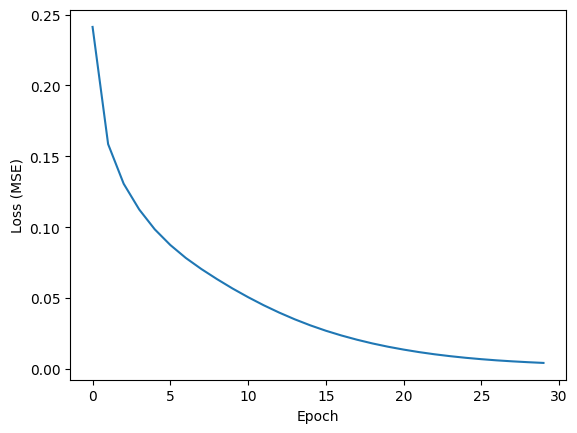

In [ ]:
#Plot average loss (for checking lr, etc.)
av_curve = np.mean(allLosses, axis=0)
plot(av_curve)
xlabel("Epoch")
ylabel("Loss (MSE)")
show()

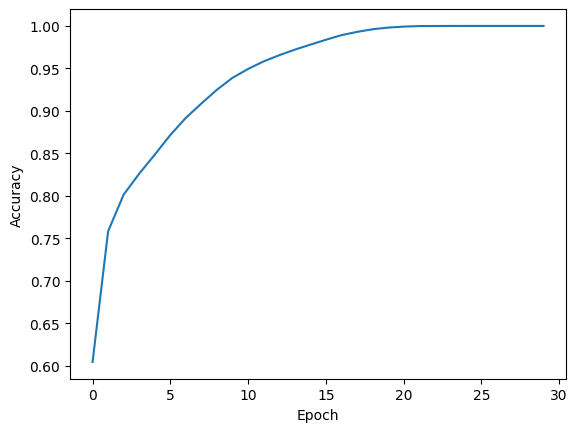

In [ ]:
#Plot average accuracy on training (for checking lr, etc.)
av_curve = np.mean(allAccs, axis=0)
plot(av_curve)
xlabel("Epoch")
ylabel("Accuracy")
show()

Print out final accuracy on different datasets: (dont use this)

In [ ]:
accuracies = {my_set:{ts:0.0 for ts in test_sets+["training"]} for my_set in stim_sets}
for my_set in accuracies.keys():
  print(my_set)

  for ts in accuracies[my_set].keys():
    print("\t"+ts)
    if ts == "training":
      test_URs, test_SRs, test_Ls = get_strings(my_set+"_train.txt")
      test_X, test_Y =get_arrays(test_URs, test_SRs, test_Ls)
      decoder_data = np.zeros(
        (len(test_X), 1, len(list(feats2symbol_sr.keys())[0].split(","))),
        dtype="float32",
      )
    else:
      test_URs, test_SRs, test_Ls, test_X, test_Y, decoder_data = processed_test_data[my_set][ts]
    if ts == "test_H":
      test_SRs = ["L EY0" for ts in test_SRs]
    these_accuracies = []

    for rep in range(reps):
      print("\t\tRep: ", rep)

      #Load a previous model:
      model = keras.models.load_model("/content/gdrive/My Drive/German-Plur-Sims/"+"Rep:"+str(rep)+",Set:"+my_set+",Attention:"+str(attention)+",LC.keras")

      #Test the model:
      Y_hat = get_test_results(model.predict([test_X, decoder_data]))
      for y, yh  in zip(test_SRs, Y_hat):
        these_accuracies.append(int(y==yh))

      # Clear away backend and output:
      backend.clear_session()
      #clear_output()
    accuracies[my_set][ts] = np.mean(these_accuracies)
clear_output()

for my_set in accuracies.keys():
  for ts in accuracies[my_set].keys():
    print(my_set+"\t"+ts+"\t"+str(accuracies[my_set][ts]))

equalFreq	test_Mutants	0.9802083333333333
equalFreq	testNewTemplates	0.8071428571428572
equalFreq	test_L	0.9947916666666666
equalFreq	test_H	1.0
equalFreq	test	1.0
equalFreq	training	1.0
minDefault	test_Mutants	0.996875
minDefault	testNewTemplates	0.8342857142857143
minDefault	test_L	0.8916666666666667
minDefault	test_H	1.0
minDefault	test	0.9993055555555556
minDefault	training	1.0
majDefault	test_Mutants	0.9697916666666667
majDefault	testNewTemplates	0.8564285714285714
majDefault	test_L	1.0
majDefault	test_H	0.955
majDefault	test	1.0
majDefault	training	1.0
